# FEATURE ENGINEERING AND MODELLING

## LOAD THE DATASET

In [1]:
import pandas as pd

clinical = pd.read_csv("clinical_day1.csv")
clinical.head()


,Disease,conditions,brief_summary,clean_summary
0,breast cancer,Breast Cancer,Breast cancer patients often have perioperativ...,breast cancer patient often perioperative emot...
1,breast cancer,Breast Cancer,Many breast cancer patients experience psychol...,many breast cancer patient experience psycholo...
2,breast cancer,Breast Neoplasm Female | Mammography Screening...,"Based on an American study by Scherer et al., ...",based american study scherer et al hypothesize...
3,breast cancer,Malignant Neoplasm of Breast,Compare the effect of ropivacaine versus place...,compare effect ropivacaine versus placebo pect...
4,breast cancer,Advanced Solid Tumor | Unresectable Solid Tumo...,Phase 1 dose escalation and expansion study of...,phase dose escalation expansion study clsp fir...


## TEXT FEATURE ENGINEERING
* Convert clean_summary into numerical features using TF‑IDF

In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000, stop_words="english")
X_text = tfidf.fit_transform(clinical['clean_summary'])

## ENCODE LABLES
* We’ll use Disease as the target for classification

In [3]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(clinical['Disease'])


## MODELLING

### CLASSIFICATION( PREDICT DISEASE FROM TEXT)

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(X_text, y, test_size=0.2, random_state=42)

clf = LogisticRegression(max_iter=200)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=le.classes_))


                                       precision    recall  f1-score   support

                              anxiety       0.90      0.95      0.92      1921
                        breast cancer       0.96      0.97      0.96      3259
chronic obstructive pulmonary disease       0.94      0.90      0.92      1251
                             covid-19       0.96      0.93      0.95      1925
                             glaucoma       0.98      0.93      0.96       456
                 rheumatoid arthritis       0.97      0.89      0.93       738
                   sickle cell anemia       0.97      0.83      0.89       227
                      type 2 diabetes       0.94      0.97      0.96      2291

                             accuracy                           0.94     12068
                            macro avg       0.95      0.92      0.94     12068
                         weighted avg       0.95      0.94      0.94     12068



## INFERENCES

* Accuracy: 94% overall

* Macro F1: 0.94 (balanced across classes)

* Weighted F1: 0.94 (accounts for class imbalance)

🔹 What this means

model is correctly predicting diseases from clean_summary text most of the time.

Strong performance across major classes like breast cancer, type 2 diabetes, covid‑19.

Slightly lower recall for smaller classes (e.g., sickle cell anemia, rheumatoid arthritis) — that’s expected because they have fewer samples.

## ELBOW METHOD TO CHOOSE NO OF CLUSTERS

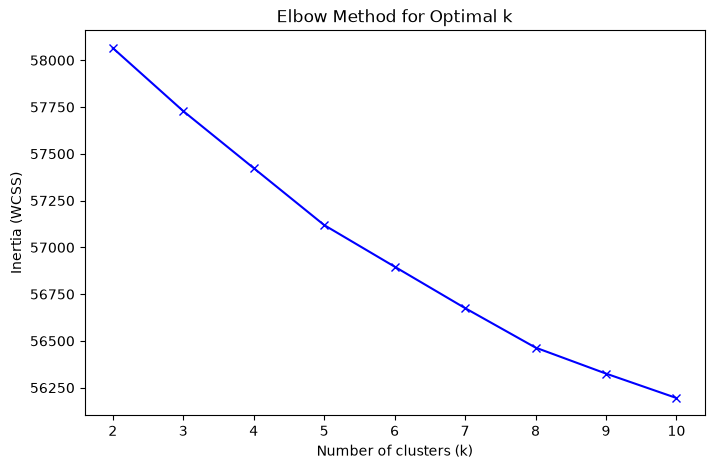

In [5]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inertia = []
K = range(2, 11)  # test cluster sizes from 2 to 10
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_text)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K, inertia, "bx-")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (WCSS)")
plt.title("Elbow Method for Optimal k")
plt.show()

## INFERENCES
* Looking at your Elbow Method plot, here’s the inference:

* The curve shows a sharp drop in inertia (WCSS) between k=2 and k=4, meaning adding clusters in that range significantly improves compactness.

* After k=4 or k=5, the curve starts to flatten — inertia still decreases, but the rate of improvement slows down.

* This “bend” or elbow point suggests that the optimal number of clusters is likely 4 or 5.

## SILHOUETTE SCORE
* This measures how well‑separated clusters are

👉 The higher the silhouette score (closer to 1), the better the clustering quality

In [6]:
from sklearn.metrics import silhouette_score

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    clusters = kmeans.fit_predict(X_text)
    score = silhouette_score(X_text, clusters)
    print(f"k={k}, silhouette={score:.3f}")

k=2, silhouette=0.008
k=3, silhouette=0.009
k=4, silhouette=0.011
k=5, silhouette=0.013
k=6, silhouette=0.012
k=7, silhouette=0.013
k=8, silhouette=0.010
k=9, silhouette=0.011
k=10, silhouette=0.010


## INFERENCES

* Scores are very low overall (all between 0.008–0.013).

* A silhouette score closer to 1.0 means well‑separated clusters.

* Scores near 0 mean clusters overlap heavily, so separation is weak.

* The highest scores are at k=5 and k=7 (≈0.013).

* The elbow plot also suggested 4–5 clusters as the point where inertia stopped dropping sharply.


* The best candidate is k=5, since it aligns with both the elbow method and the highest silhouette score.

* k=7 also gives a similar silhouette score, but the elbow plot didn’t show a clear bend there, so 5 is more consistent.

* The low silhouette values overall suggest that your text features (TF‑IDF) may not separate diseases strongly — this is common in clinical text because descriptions overlap.

## CLUSTERING(GROUP TRAILS BY SIMILARITY)

In [7]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_text)

print("Silhouette Score:", silhouette_score(X_text, clusters))
clinical["Cluster"] = clusters

Silhouette Score: 0.012518496490614523


## INFERENCES
* The silhouette score = 0.0125 is very low.

* Scores close to 0 mean clusters overlap heavily and aren’t well separated.

* This is common with TF‑IDF text features in clinical summaries, because the language across diseases is similar.

### INSPECT CLUSTER DISTRIBUTION

In [8]:
clinical['Cluster'].value_counts()


Cluster
4    20779
1    12181
2    11640
3     7976
0     7761
Name: count, dtype: int64

### INSPECT CLUSTER COMPOSITION

In [9]:
cluster_summary = clinical.groupby("Cluster")["Disease"].value_counts()
print(cluster_summary)

Cluster  Disease                              
0        covid-19                                  7716
         breast cancer                               18
         chronic obstructive pulmonary disease        8
         anxiety                                      8
         rheumatoid arthritis                         7
         sickle cell anemia                           4
1        anxiety                                   7864
         breast cancer                             1374
         covid-19                                  1038
         type 2 diabetes                            881
         chronic obstructive pulmonary disease      637
         rheumatoid arthritis                       200
         sickle cell anemia                         156
         glaucoma                                    31
2        breast cancer                            11564
         anxiety                                     39
         covid-19                                    14
 

## INFERENCES

* Cluster Breakdown
* Cluster 0 → Almost entirely COVID‑19 trials (7,716 out of 7,761).
→ This cluster is clearly “COVID‑19 dominant.”

* Cluster 1 → Mixed, but dominated by Anxiety (7,864) with smaller groups of breast cancer, diabetes, COPD, etc.
→ This looks like the “Mental health / mixed” cluster.

* Cluster 2 → Overwhelmingly Breast Cancer (11,564 out of 11,640).
→ Very clean “Breast Cancer cluster.”

* Cluster 3 → Almost entirely Type 2 Diabetes (7,896 out of 7,976).
→ Strong “Diabetes cluster.”

* Cluster 4 → The most diverse cluster:

COPD (5,511)

Rheumatoid arthritis (3,423)

Breast cancer (3,329)

Type 2 diabetes (2,684)

Glaucoma (2,141)

Anxiety (1,360)

COVID‑19 (1,354)

Sickle cell anemia (977)
→ This is a mixed cluster, capturing diseases with overlapping text patterns.

## FINAL INFERENCES
* Clusters 0, 2, 3 are very clean and disease‑specific (COVID‑19, Breast Cancer, Diabetes).

* Cluster 1 is dominated by Anxiety, but includes spillover from other diseases.

* Cluster 4 is a catch‑all cluster with multiple diseases — this happens because TF‑IDF text features overlap across trial summaries.

## CLUSTER LABELS
* Assign human‑readable names for dashboard clarity

In [11]:
cluster_names = {
    0: "COVID-19 Trials",
    1: "Anxiety & Mental Health",
    2: "Breast Cancer Trials",
    3: "Diabetes Trials",
    4: "Mixed / Autoimmune & Others",
}
clinical["Cluster_Label"] = clinical["Cluster"].map(cluster_names)

## VISUALIZE CLUSTER DISTRIBUTION

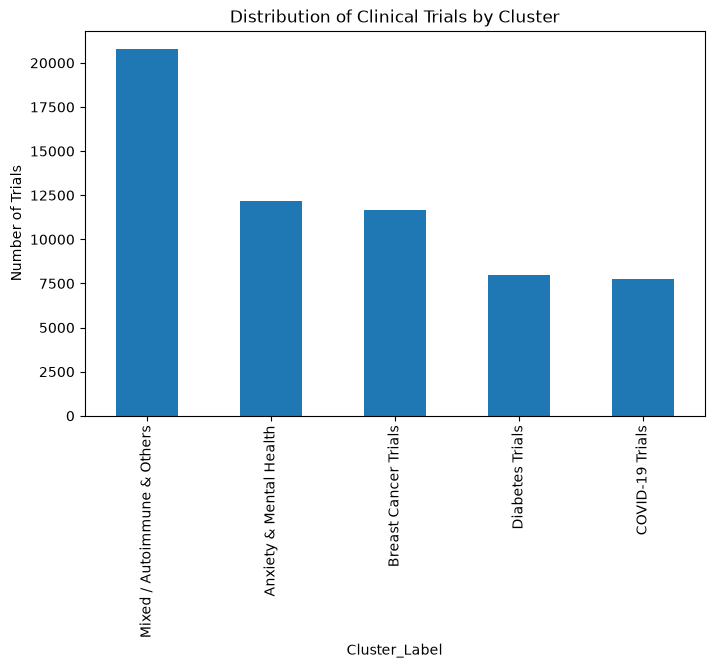

In [13]:
import matplotlib.pyplot as plt

clinical["Cluster_Label"].value_counts().plot(kind="bar", figsize=(8, 5))
plt.title("Distribution of Clinical Trials by Cluster")
plt.ylabel("Number of Trials")
plt.show()

## VISUVALIZE CLUSTER IN 2D

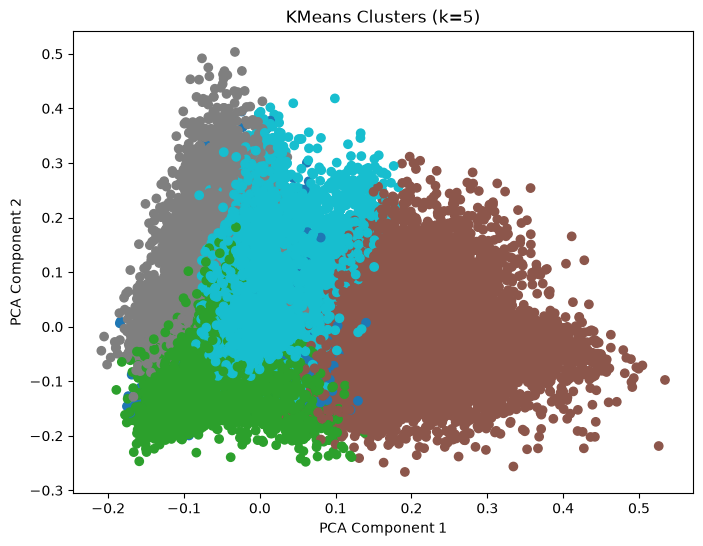

In [14]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
reduced = pca.fit_transform(X_text.toarray())

plt.figure(figsize=(8, 6))
plt.scatter(reduced[:, 0], reduced[:, 1], c=clinical["Cluster"], cmap="tab10")
plt.title("KMeans Clusters (k=5)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

## INFERENCES
* Clusters 0, 2, 3 are disease‑specific and well‑defined.

* Clusters 1 and 4 are heterogeneous, capturing overlapping language across multiple conditions.

* The PCA plot confirms what your counts showed: some clusters are clean, while others are catch‑all groups.

## SIMILARITY SEARCH(RECOMMEND RELATED TRAILS)

In [15]:
from sklearn.metrics.pairwise import cosine_similarity

# Compute similarity matrix once
similarity_matrix = cosine_similarity(X_text)


# Function to get top-N similar trials
def get_similar_trials(index, n=5):
    """
    Returns the top-n most similar trials to the given index.

    Parameters:
    index (int): Row index of the trial in the dataframe
    n (int): Number of similar trials to return

    Returns:
    DataFrame: Subset of clinical dataframe with similar trials
    """
    # Get similarity scores for the trial
    scores = list(enumerate(similarity_matrix[index]))

    # Sort by similarity (highest first)
    scores = sorted(scores, key=lambda x: x[1], reverse=True)

    # Skip the trial itself (index) and take top-n
    top_indices = [i for i, _ in scores[1 : n + 1]]

    return clinical.iloc[top_indices][["Disease", "clean_summary", "Cluster_Label"]]


# Example usage: find 5 trials similar to trial 0
similar_trials = get_similar_trials(0, n=5)
print(similar_trials)

             Disease                                      clean_summary  \
14717  breast cancer  esketamine optical isomer ketamine compared ke...   
57715        anxiety  depression common patient cancer current medic...   
16751       covid-19  plain language summary study clinical trial se...   
53855        anxiety  ketamine shown decrease symptom anxious depres...   
8      breast cancer  goal clinical trial compare effectiveness ultr...   

                     Cluster_Label  
14717      Anxiety & Mental Health  
57715      Anxiety & Mental Health  
16751              COVID-19 Trials  
53855  Mixed / Autoimmune & Others  
8             Breast Cancer Trials  


In [7]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(X_text)

# Example: find top 5 similar trials to trial 0
similar_trials = similarity_matrix[0].argsort()[-6:-1]
print("Trials similar to trial 0:", similar_trials)


Trials similar to trial 0: [    8 53855 16751 57715 14717]


## SAVE THE DATASET
